In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("winequality-red.csv")

#if wine quality >= 6 then its good(1) else it is bad (0)
df["quality"] = (df["quality"] >= 6).astype(int)
X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
def add_noise(X, noise_level):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

noise_levels = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
accuracies = []
for noise in noise_levels:
  
    X_train_noise = add_noise(X_train_scaled, noise)
    X_test_noise = add_noise(X_test_scaled, noise)

    model = SVC(kernel="rbf", C=1)
    model.fit(X_train_noise, y_train)

    y_pred = model.predict(X_test_noise)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Noise Level: {noise}, Accuracy: {acc:.4f}")

Noise Level: 0, Accuracy: 0.7719
Noise Level: 0.01, Accuracy: 0.7719
Noise Level: 0.05, Accuracy: 0.7688
Noise Level: 0.1, Accuracy: 0.7562
Noise Level: 0.2, Accuracy: 0.7625
Noise Level: 0.3, Accuracy: 0.7375
Noise Level: 0.5, Accuracy: 0.7500


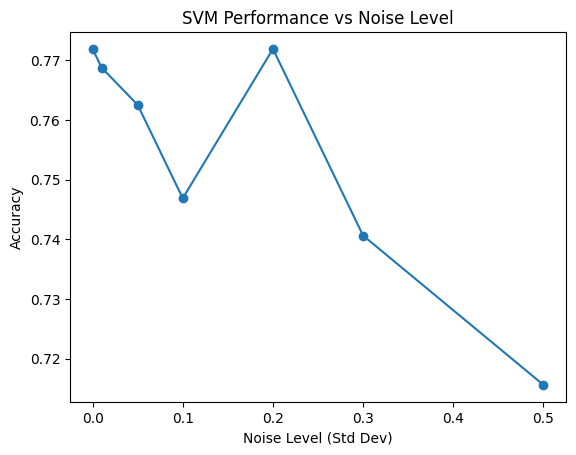

In [4]:
plt.figure()
plt.plot(noise_levels, accuracies, marker='o')
plt.xlabel("Noise Level (Std Dev)")
plt.ylabel("Accuracy")
plt.title("SVM Performance vs Noise Level")
plt.show()